Best pair to pick: ([17, 1], [73, 4])
Best expected total profit: 265557.24


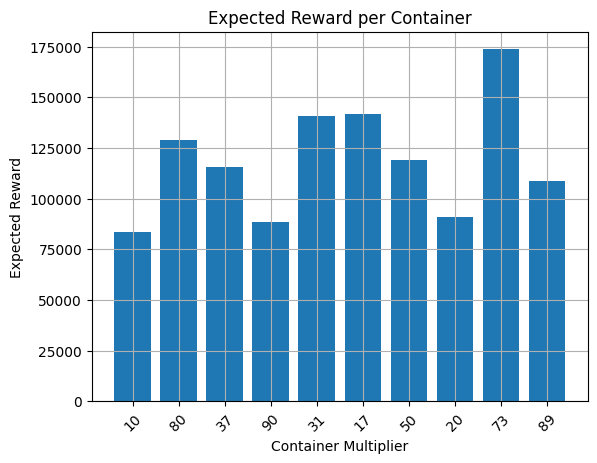

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

coins = 10000
data = [[10, 1], [80, 6], [37, 3], [90, 10], [31, 2], [17, 1], [50, 4], [20, 2], [73, 4], [89, 8]]

def choose():
    return np.random.permutation(10)[:2]

def simulate(trials=10000, second_pick_cost=50000):
    picks = np.zeros(10)

    for _ in range(trials):
        first, second = choose()
        picks[first] += 1
        picks[second] += 1

    expected_rewards = []
    for i, (multiplier, inhabitants) in enumerate(data):
        pick_fraction = picks[i] / trials
        divisor = inhabitants + pick_fraction
        reward = (coins * multiplier) / divisor
        expected_rewards.append(reward)

    best_pair = None
    best_profit = -float('inf')

    for i in range(10):
        for j in range(10):
            if i == j:
                continue
            profit = expected_rewards[i] + expected_rewards[j] - second_pick_cost
            if profit > best_profit:
                best_profit = profit
                best_pair = (data[i], data[j])


    return {
        "pick_frequencies": picks,
        "expected_rewards": expected_rewards,
        "best_pair": best_pair,
        "best_expected_total_profit": best_profit
    }

results = simulate()
print(f"Best pair to pick: {results['best_pair']}")
print(f"Best expected total profit: {results['best_expected_total_profit']:.2f}")

multipliers = [str(d[0]) for d in data]
plt.bar(multipliers, results["expected_rewards"])
plt.xticks(multipliers, rotation=45)
plt.xlabel("Container Multiplier")
plt.ylabel("Expected Reward")
plt.title("Expected Reward per Container")
plt.grid(True)
plt.show()
